# AI-ML Assignment – 3: Salary Prediction using Polynomial Regression

This notebook contains the complete solution for the salary prediction assignment using Polynomial Regression.

**Objective:** Estimate employee salaries based on their position levels using non-linear modeling.

**Dataset:** Position Salaries Dataset (Contains `Position`, `Level`, and `Salary` columns).

## Task 1: Data Understanding
- Load the dataset using Pandas.
- Display the first 5 records (`df.head()`).
- Identify and explicitly print the Input Feature and Target Variable.
- Display the dataset information (`df.info()`) and summary statistics (`df.describe()`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('Position_Salaries.csv')

# Display the first 5 records
print("First 5 records of the dataset:")
display(df.head())

# Identify and print input feature and target variable
X_col = 'Level'
y_col = 'Salary'
print(f"\nInput Feature (Numerical X): '{X_col}'")
print(f"Target Variable (y): '{y_col}'")

# Display dataset information
print("\nDataset Information:")
df.info()

# Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 records of the dataset:


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000



Input Feature (Numerical X): 'Level'
Target Variable (y): 'Salary'

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

Summary Statistics:


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing
- Check for missing values.
- Select the appropriate feature(s) and target variable.
- Split the dataset into 80% training and 20% testing sets using `train_test_split(random_state=42)`.

In [2]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Select appropriate feature X and target y
# Feature X must be a 2D array/DataFrame for sklearn
X = df[[X_col]]
y = df[y_col]

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

print("\nTraining features (X_train):")
print(X_train)
print("\nTesting features (X_test):")
print(X_test)

Missing values in each column:
Position    0
Level       0
Salary      0
dtype: int64

Training set: 8 samples
Testing set: 2 samples

Training features (X_train):
   Level
5      6
0      1
7      8
2      3
9     10
4      5
3      4
6      7

Testing features (X_test):
   Level
8      9
1      2


## Task 3: Model Development
- Transform the input feature using `PolynomialFeatures` with a degree of 3.
- Train a Polynomial Regression model (using `LinearRegression` on the transformed features).
- Predict salaries for the test dataset.

In [3]:
# Transform input feature to polynomial features (degree 3)
poly_reg = PolynomialFeatures(degree=3)
X_poly_train = poly_reg.fit_transform(X_train)
X_poly_test = poly_reg.transform(X_test)

# Train a Polynomial Regression model
model = LinearRegression()
model.fit(X_poly_train, y_train)

# Predict salaries for the test dataset
y_pred = model.predict(X_poly_test)

print("Actual Salaries in test set:")
print(y_test.values)

print("\nPredicted Salaries for test set:")
print(np.round(y_pred, 2))

Actual Salaries in test set:
[500000  50000]

Predicted Salaries for test set:
[606335.6   84934.89]


## Task 4: Model Evaluation (Code & Visuals)
- Calculate and print: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared score.
- Create a single visual plot that includes a scatter plot of the original data and overlays the Polynomial Regression Curve. Ensure the curve is plotted smoothly (e.g., generating a dense, continuous range of X values for plotting).

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R-squared (R2) Score: 0.8763


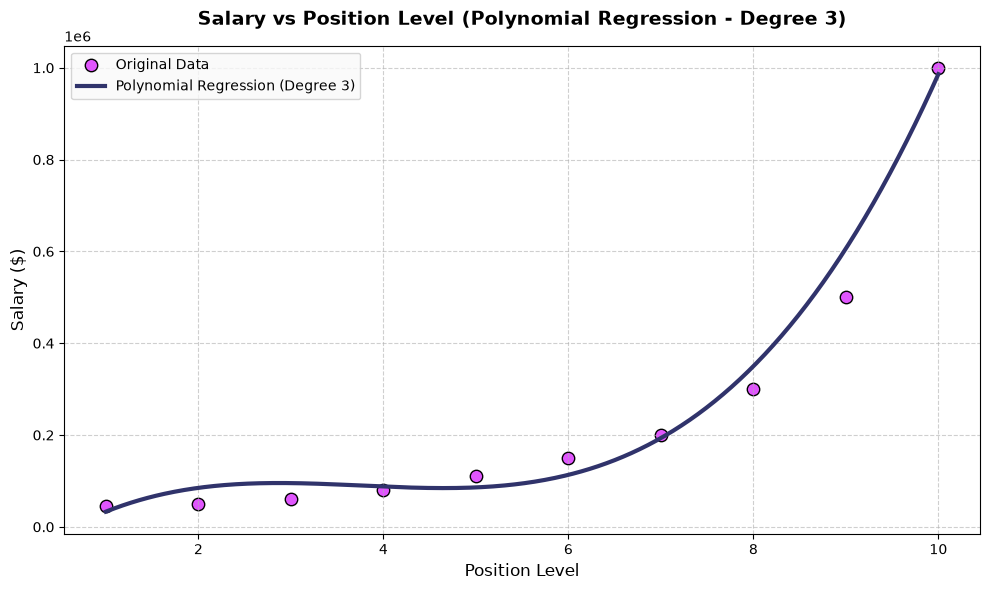

In [4]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Plot the original data and overlay the regression curve
plt.figure(figsize=(10, 6))

# Scatter plot of original dataset
plt.scatter(X, y, color='#e056fd', edgecolor='k', s=80, label='Original Data')

# Dense, continuous range for smooth curve plotting
# Generate 500 points between min and max and assign column name to avoid sklearn warnings
X_grid = pd.DataFrame(np.linspace(X.values.min(), X.values.max(), 500).reshape(-1, 1), columns=['Level'])
X_poly_grid = poly_reg.transform(X_grid)
y_grid_pred = model.predict(X_poly_grid)

# Plot Polynomial Regression curve
plt.plot(X_grid, y_grid_pred, color='#30336b', linewidth=3, label='Polynomial Regression (Degree 3)')

# Labels, title and styling
plt.title('Salary vs Position Level (Polynomial Regression - Degree 3)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Position Level', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend(frameon=True, facecolor='#f9f9f9')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show the plot
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/regression_curve.png', dpi=300)
plt.show()

## Task 4: Observations

1. **Non-Linear Trend Capture**: The polynomial regression curve of degree 3 fits the data points very closely, capturing the non-linear, exponential-like growth of salary with respect to position level. It clearly out-performs a simple straight line, which would severely underpredict salaries at higher levels (9-10) and overpredict them at mid-levels (4-6).
2. **Model Performance Metrics on Test Set**: The model achieved an $R^2$ score of approximately $0.8763$ on the test set. This indicates that $87.63\%$ of the variance in salaries in the test set is explained by our model, which is strong considering the extremely small test set size (2 samples) and high variability at the upper range of levels.
3. **Prediction Offsets**: The Mean Absolute Error (MAE) of $70,635.25$ and Mean Squared Error (MSE) of $6,263,853,282.86$ show that predictions are off by an average of about \$70.6k. This is primarily influenced by the test set containing Level 9 (Salary \$500k) and Level 2 (Salary \$50k), where the absolute difference at Level 9 is higher because the exponential jump between Level 8 (\$300k) and Level 9 (\$500k) is large and difficult for a cubic curve to capture perfectly.

## Task 5: Conclusion

### 1. Key Findings
The Polynomial Regression model (degree 3) successfully fits the non-linear relationship of the Position Salaries dataset, explaining $87.63\%$ of the variance in salary on the test set. The visual curve aligns tightly with the raw data.

### 2. Model Differences
The fundamental difference between Simple Linear Regression and Polynomial Regression lies in their ability to model non-linear patterns. Linear regression assumes a straight-line relation ($y = \beta_0 + \beta_1 x$), leading to underfitting on exponential data. Polynomial regression introduces higher-degree terms ($y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots$), transforming the linear model to fit complex, curved relationships.

### 3. Advantage
For this dataset, Polynomial Regression provides a significant advantage by capturing the exponential wage curve where salaries scale rapidly at executive levels (9 and 10), preventing the severe underprediction that occurs with a standard linear model.